## Dataset Description

In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [134]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [135]:
df.shape

(6607, 20)

In [136]:
df.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


## Feature Description


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

## Central Tendency and Dispersion 

In [138]:
num_cols = df.select_dtypes(include='number').columns

print("There are", len(num_cols) ," number of columns")
print("The Numerical Columns are: ", list(num_cols))


There are 7  number of columns
The Numerical Columns are:  ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [139]:
calculation = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "IQR": df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
})

calculation

,Mean,Median,Mode,Variance,Std Dev,IQR
Hours_Studied,19.975329,20.0,20,35.887221,5.990594,8.0
Attendance,79.977448,80.0,67,133.344178,11.547475,20.0
Sleep_Hours,7.029060,7.0,7,2.155377,1.468120,2.0
Previous_Scores,75.070531,75.0,66,207.353789,14.399784,25.0
Tutoring_Sessions,1.493719,1.0,1,1.514304,1.230570,1.0
Physical_Activity,2.967610,3.0,3,1.063438,1.031231,2.0
Exam_Score,67.235659,67.0,68,15.135646,3.890456,4.0


Distribution and Shape

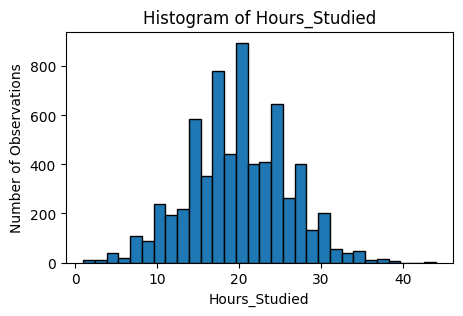

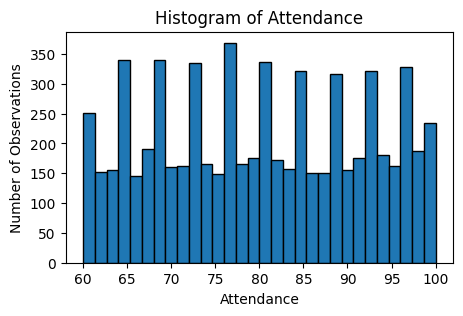

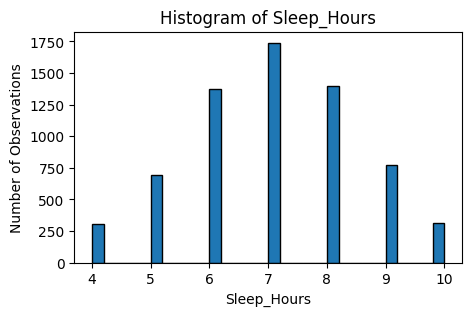

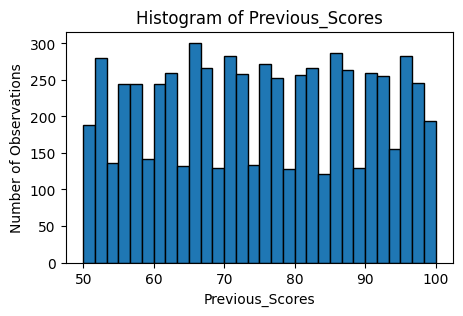

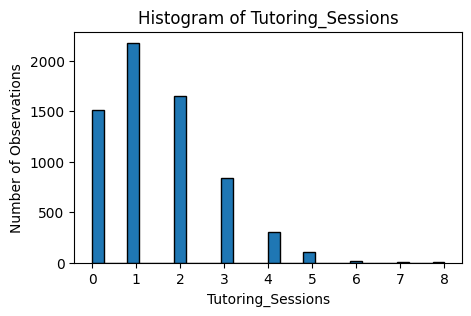

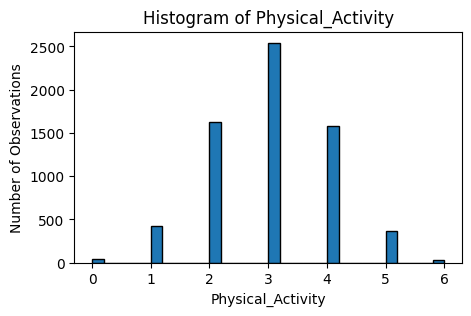

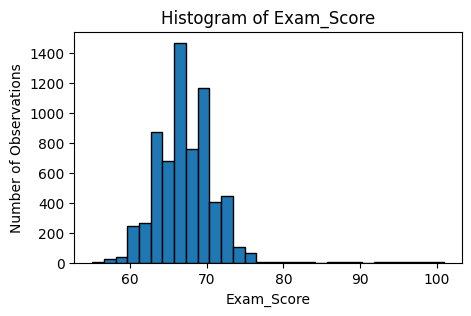

In [140]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    df[col].plot(kind='hist',edgecolor = 'black',bins = 30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Number of Observations')
    plt.show()

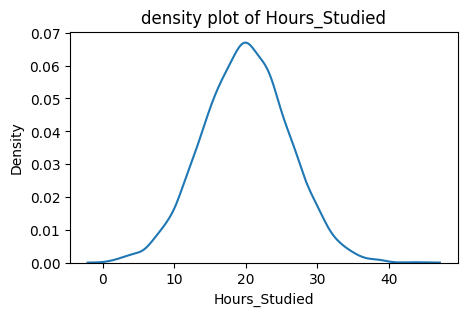

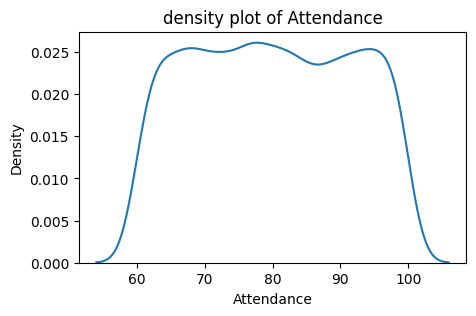

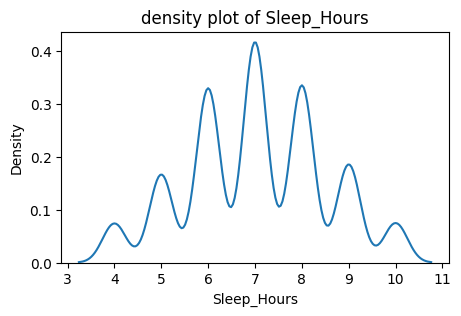

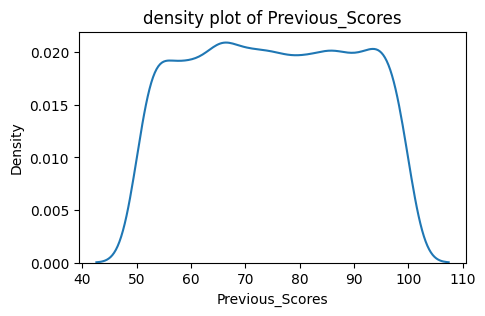

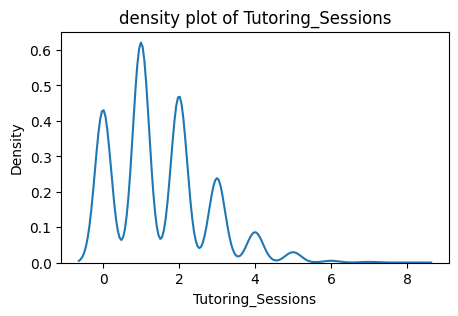

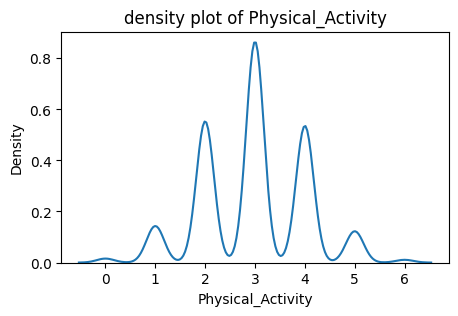

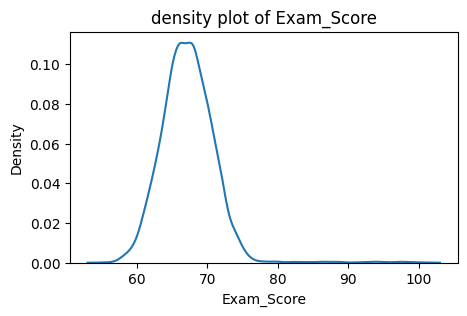

In [141]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(df[col])
    plt.title(f"density plot of {col}")
    plt.xlabel(f'{col}')
    plt.ylabel('Density')
    plt.show()

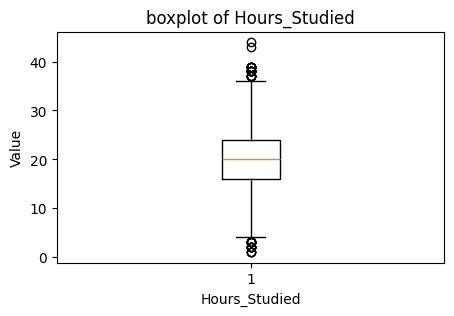

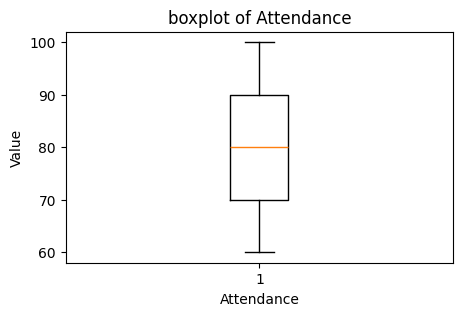

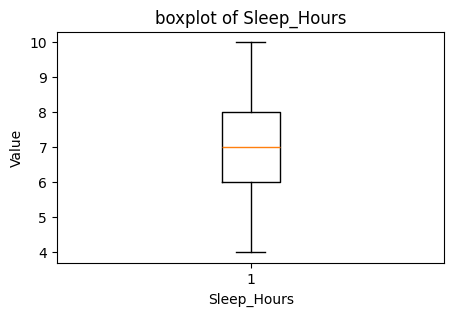

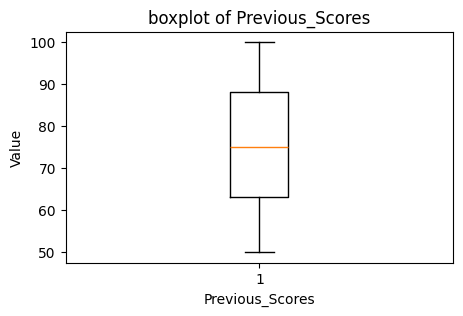

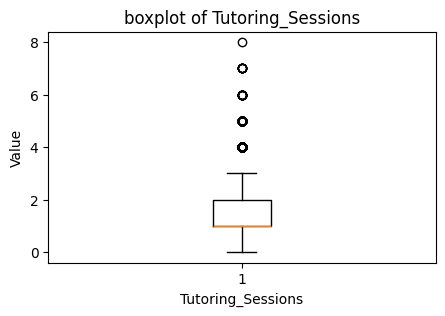

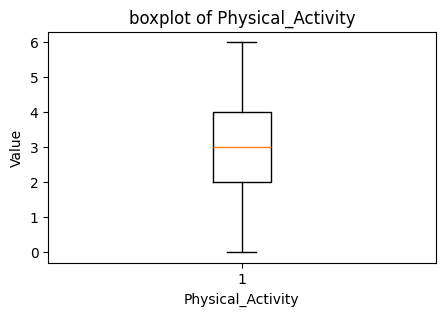

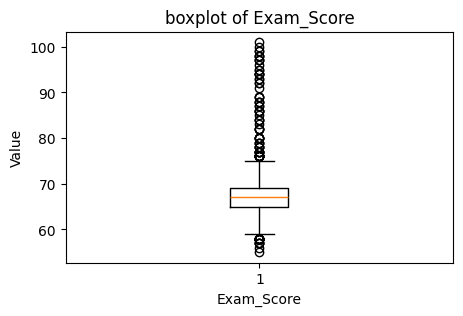

In [142]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(f"boxplot of {col}")
    plt.xlabel(f'{col}')
    plt.ylabel('Value')
    plt.show()

In [143]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df[num_cols] < Q1 - 1.5*IQR) | (df[num_cols] > Q3 + 1.5*IQR)]
print("Number of outliers in each column:")
print(outliers[num_cols].count())

Number of outliers in each column:
Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64


**Interpretation:**
- Skewness ≈ 0 → Symmetric
- Skewness > 0 → Right-skewed
- Skewness < 0 → Left-skewed

In [144]:
skewness = df[num_cols].skew()

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df

,Feature,Skewness
0,Hours_Studied,0.013499
1,Attendance,0.013666
2,Sleep_Hours,-0.023805
3,Previous_Scores,-0.003737
4,Tutoring_Sessions,0.815530
5,Physical_Activity,-0.031365
6,Exam_Score,1.644808


In [145]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary[col] = count

outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=["Feature", "Outlier Count"])
outlier_df

,Feature,Outlier Count
0,Hours_Studied,43
1,Attendance,0
2,Sleep_Hours,0
3,Previous_Scores,0
4,Tutoring_Sessions,430
5,Physical_Activity,0
6,Exam_Score,104


## Categorical Variable Analysis

In [146]:
cat_cols = df.select_dtypes(include=['object','string']).columns

print("There are ", len(cat_cols)," categorical features")
print("The Categorical Columns are: ", list(cat_cols))



There are  13  categorical features
The Categorical Columns are:  ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [147]:
for col in cat_cols:
    print(f"Frequency Table for: {col}")
    
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = ['Category', 'Count']
  
    print(freq_table.to_string(index=False))

Frequency Table for: Parental_Involvement
Category  Count
  Medium   3362
    High   1908
     Low   1337
Frequency Table for: Access_to_Resources
Category  Count
  Medium   3319
    High   1975
     Low   1313
Frequency Table for: Extracurricular_Activities
Category  Count
     Yes   3938
      No   2669
Frequency Table for: Motivation_Level
Category  Count
  Medium   3351
     Low   1937
    High   1319
Frequency Table for: Internet_Access
Category  Count
     Yes   6108
      No    499
Frequency Table for: Family_Income
Category  Count
     Low   2672
  Medium   2666
    High   1269
Frequency Table for: Teacher_Quality
Category  Count
  Medium   3925
    High   1947
     Low    657
Frequency Table for: School_Type
Category  Count
  Public   4598
 Private   2009
Frequency Table for: Peer_Influence
Category  Count
Positive   2638
 Neutral   2592
Negative   1377
Frequency Table for: Learning_Disabilities
Category  Count
      No   5912
     Yes    695
Frequency Table for: Parental_Educ

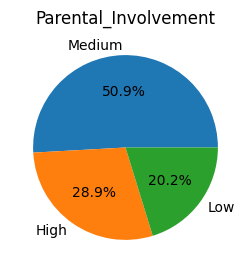

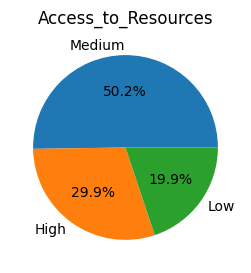

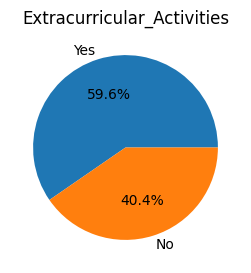

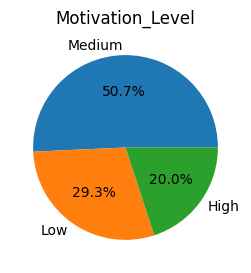

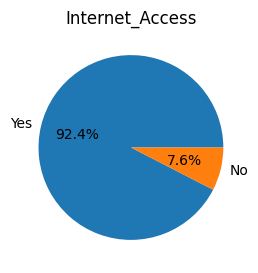

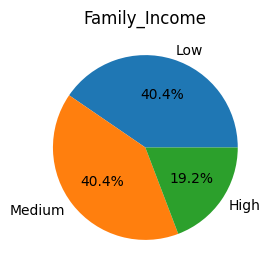

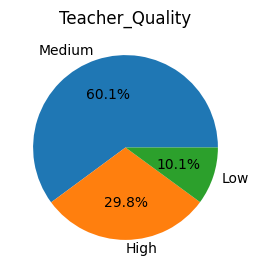

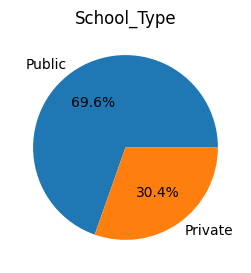

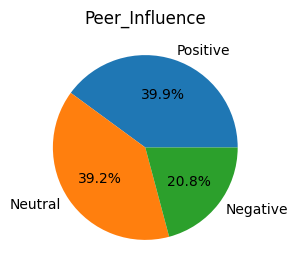

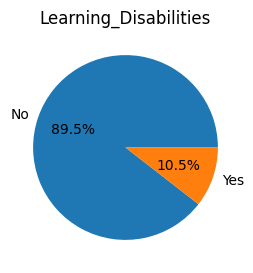

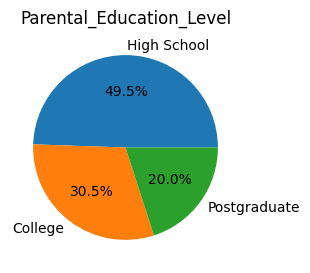

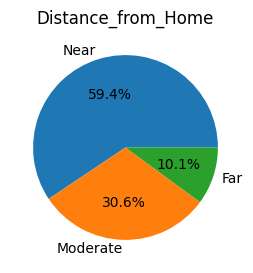

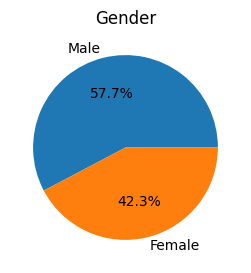

In [148]:
for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%',figsize=(5,3))
    plt.title(col)
    plt.show()

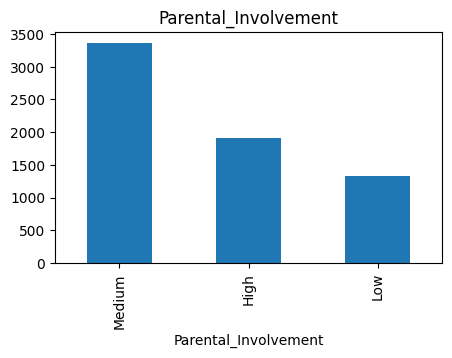

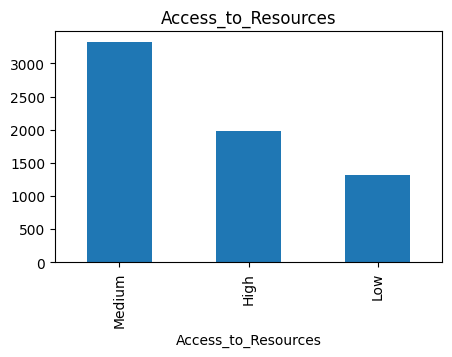

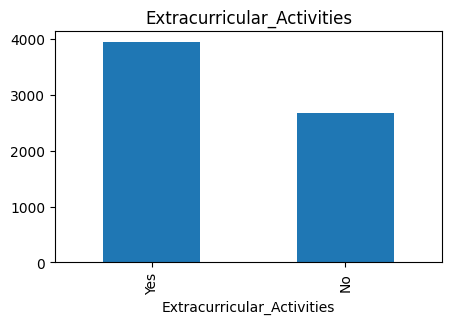

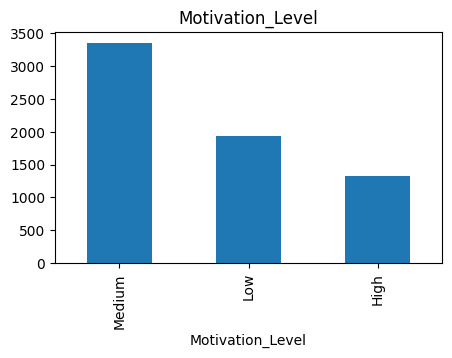

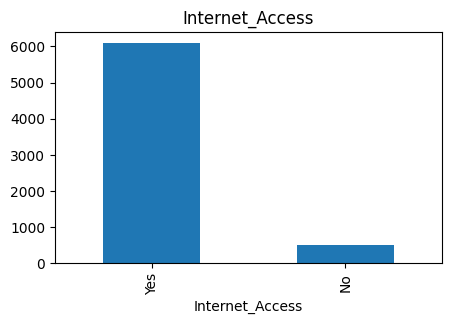

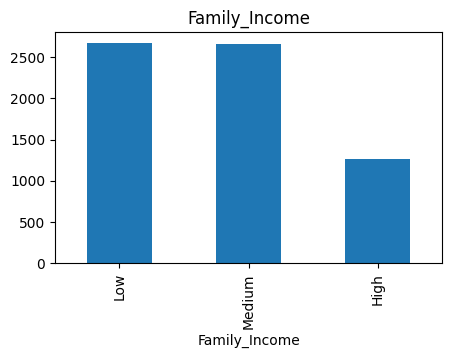

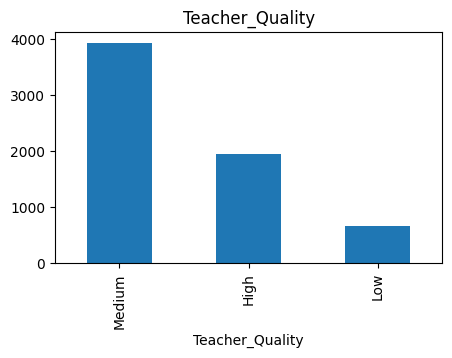

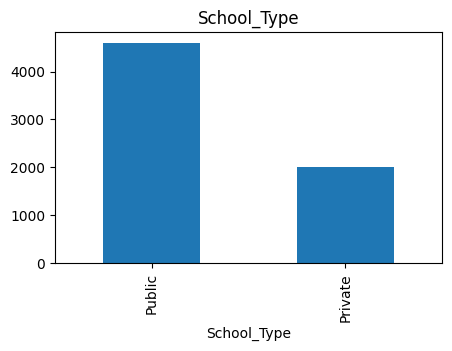

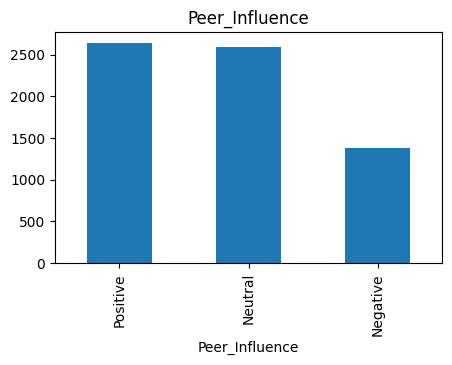

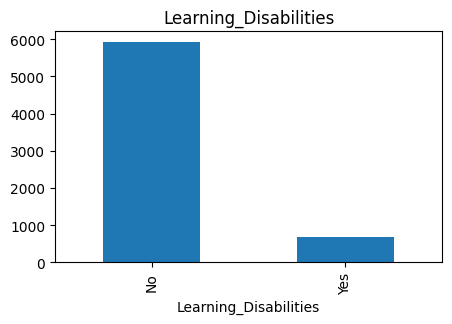

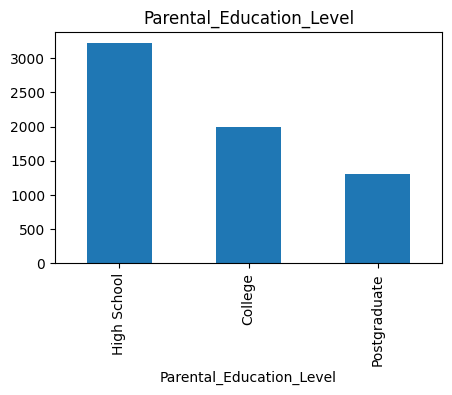

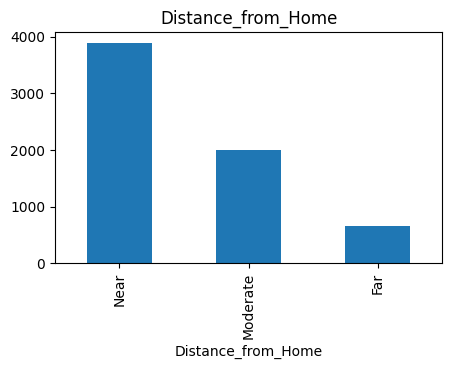

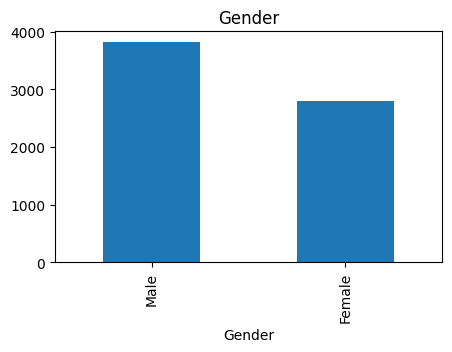

In [149]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar', figsize=(5,3))
    plt.title(col)
    plt.show()

## Relationships Between Variables

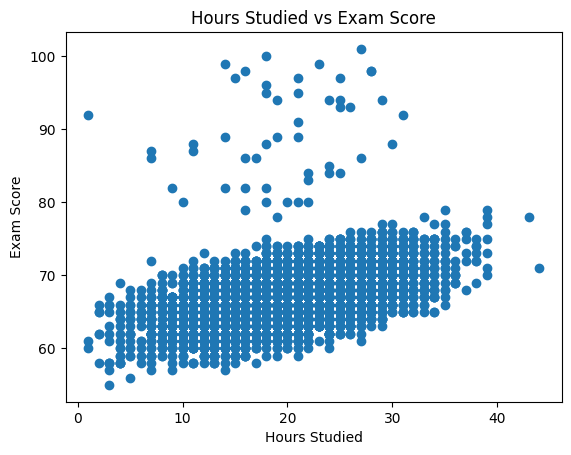

In [150]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

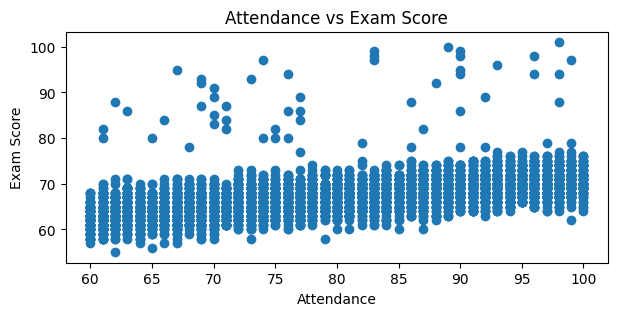

In [151]:
plt.figure(figsize=(7,3))
plt.scatter(df['Attendance'],df['Exam_Score'])
plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.title('Attendance vs Exam Score')
plt.show()

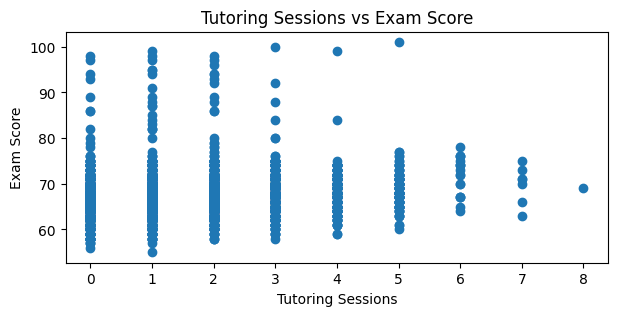

In [152]:
plt.figure(figsize=(7,3))
plt.scatter(df['Tutoring_Sessions'], df['Exam_Score'])
plt.xlabel('Tutoring Sessions')
plt.ylabel('Exam Score')
plt.title('Tutoring Sessions vs Exam Score')
plt.show()

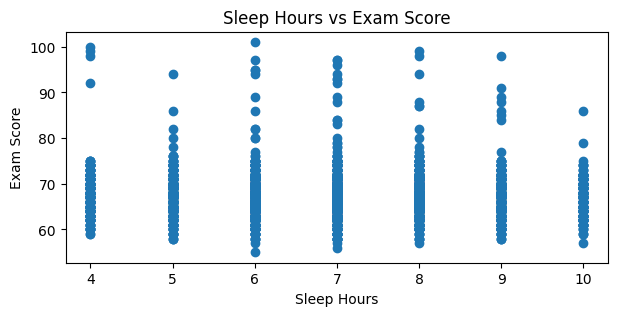

In [153]:
plt.figure(figsize=(7,3))
plt.scatter(df['Sleep_Hours'], df['Exam_Score'])
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.title('Sleep Hours vs Exam Score')
plt.show()

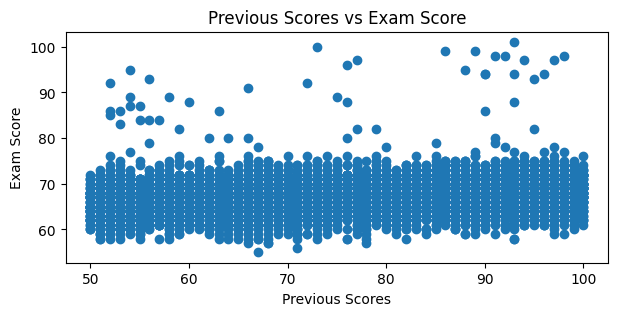

In [154]:
plt.figure(figsize=(7,3))
plt.scatter(df['Previous_Scores'], df['Exam_Score'])
plt.xlabel('Previous Scores')
plt.ylabel('Exam Score')
plt.title('Previous Scores vs Exam Score')
plt.show()

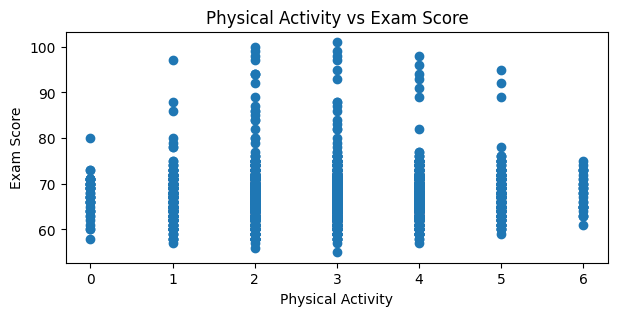

In [155]:
plt.figure(figsize=(7,3))
plt.scatter(df['Physical_Activity'], df['Exam_Score'])
plt.xlabel('Physical Activity')
plt.ylabel('Exam Score')
plt.title('Physical Activity vs Exam Score')
plt.show()

## Data Quality Assessment

In [156]:
df.isnull().sum()


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000
